In [1]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
from shapely import wkt
import altair as alt
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import shutil
import subprocess
import os
import folium
import folium.plugins
import datetime
alt.data_transformers.disable_max_rows()
import warnings
warnings.filterwarnings("ignore")



os.environ["JAVA_HOME"] = subprocess.run(
    ["/usr/libexec/java_home", "-v", "21"],
    capture_output=True, text=True, check=True
).stdout.strip()


from r5py.util.config import Config
import r5py

Number of intersections:  166596
Number of road segments: 509190


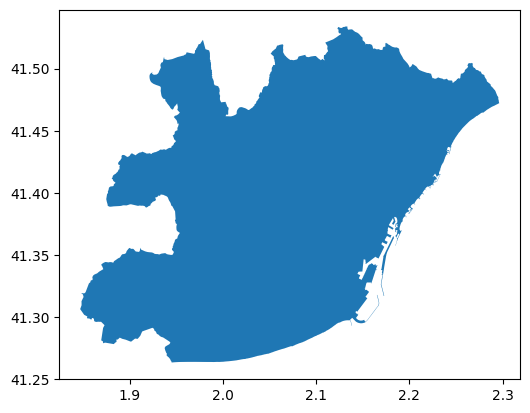

In [2]:
# Importing osmnx

# Define the polygon for the 1st district of Budapest
admin_district = ox.geocode_to_gdf('Àrea Metropolitana de Barcelona, Spain')
admin_district.plot()
admin_poly = admin_district.geometry.values[0]

# Load the graph from OSMnx
G = ox.graph_from_polygon(admin_poly, network_type='walk')

print('Number of intersections: ', G.number_of_nodes())
print('Number of road segments:',  G.number_of_edges())

In [3]:
neigh = pd.read_csv("Data/Neigh/neigh.csv")

neigh["geometry"] = neigh["geom"].apply(wkt.loads)

neigh = gpd.GeoDataFrame(
    neigh,
    geometry="geometry",
    crs="EPSG:4326"
)
neigh = neigh[["name", "geometry"]]
neigh["geometry"] = neigh.buffer(0)


neigh_layer = alt.Chart(neigh).mark_geoshape(
    stroke="black",
    fill="lightblue"
).properties(
    width=600,
    height=600
    
).encode(tooltip=['name'])

In [5]:
bus_sol = pd.read_csv('Nodes/N-Bus-Sol.csv')
bus = pd.read_csv('Nodes/N-Bus.csv')
fgc_sol = pd.read_csv('Nodes/N-FGC-Sol.csv')
fgc = pd.read_csv('Nodes/N-FGC.csv')
metro_sol = pd.read_csv('Nodes/N-Metro-Sol.csv')
metro = pd.read_csv('Nodes/N-Metro.csv')
tram_sol = pd.read_csv('Nodes/N-Tram-Sol.csv')
tram = pd.read_csv('Nodes/N-Tram.csv')
destinations = pd.read_csv('Nodes/N-POIs.csv')

all_stops = pd.concat([bus_sol, bus, fgc_sol, fgc, metro_sol, metro, tram_sol, tram], ignore_index=True)
all_stops['geometry']= all_stops['geometry'].apply(wkt.loads)
all_stops = gpd.GeoDataFrame(all_stops, geometry='geometry', crs="EPSG:4326")

destinations['geometry']= destinations['geometry'].apply(wkt.loads)
destinations = gpd.GeoDataFrame(destinations, geometry='geometry', crs="EPSG:4326")
#all_stops = all_stops[:100]


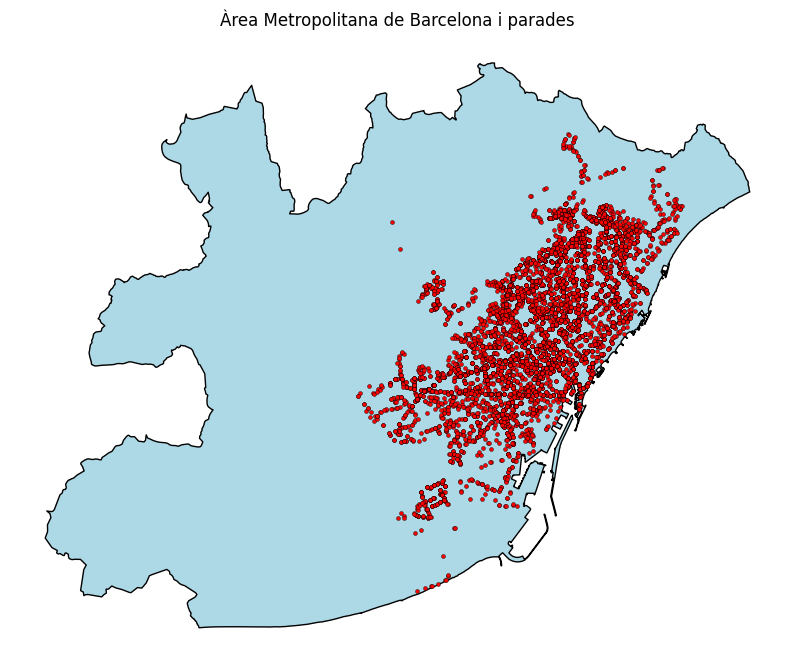

In [6]:
fig, ax = plt.subplots(figsize=(10, 10))

admin_district.plot(
    ax=ax,
    color="lightblue",
    edgecolor="black",
    linewidth=1
)

all_stops.plot(
    ax=ax,
    color="red",
    markersize=8,
    edgecolor="black",
    linewidth=0.3
)

ax.set_title("Àrea Metropolitana de Barcelona i parades")
ax.axis("off")
plt.show()

In [10]:
all_stops[all_stops['stop_id'] == 314]

,id,stop_id,name,linia,stop_type,geometry
1339,B-141-314,314,Calàbria - Gran Via,141,Bus,POINT (2.15474 41.37998)
6572,SM-314,314,Zona Universitària,IU Stop,Metro,POINT (2.11139 41.384)
6681,M-L3-314,314,Zona Universitària,L3,Metro,POINT (2.11139 41.384)


In [34]:
walking_speed = 1.39

for u, v, data in G.edges(data=True):
    data["travel_time"] = data["length"] / walking_speed


isochrone_time = 7.5
isochrone_polys = []

process = 1
for stop_type in all_stops['stop_type'].unique():
    stops_of_type = all_stops[all_stops['stop_type'] == stop_type]
    for stop in stops_of_type['stop_id'].unique():
        print(f"Processing stop {stop} ({process}/{len(all_stops['stop_id'].unique())})")
        process += 1
        p = stops_of_type[stops_of_type['stop_id'] == stop].iloc[0]
        center_node = ox.distance.nearest_nodes(G, X=p['geometry'].x, Y=p["geometry"].y)

        subgraph = nx.ego_graph(
                G,
                center_node,
                radius= isochrone_time * 60,
                distance="travel_time"
            )

        node_points = [
            Point((data["x"], data["y"]))
            for node, data in subgraph.nodes(data=True)
        ]

        center_point = Point(G.nodes[center_node]["x"], G.nodes[center_node]["y"])

        polygon = gpd.GeoSeries(node_points).union_all().convex_hull
        isochrone_polys.append(
                gpd.GeoDataFrame(
                    {"stop_id": [p["stop_id"]], "stop_type": [p["stop_type"]], "geometry": [polygon]},
                    crs="EPSG:4326"
                )
            )

isochrone_polys = gpd.GeoDataFrame(pd.concat(isochrone_polys, ignore_index=True), crs="EPSG:4326")

Processing stop 2 (1/3267)
Processing stop 3 (2/3267)
Processing stop 7 (3/3267)
Processing stop 8 (4/3267)
Processing stop 13 (5/3267)
Processing stop 20 (6/3267)
Processing stop 21 (7/3267)
Processing stop 22 (8/3267)
Processing stop 24 (9/3267)
Processing stop 25 (10/3267)
Processing stop 31 (11/3267)
Processing stop 32 (12/3267)
Processing stop 34 (13/3267)
Processing stop 38 (14/3267)
Processing stop 39 (15/3267)
Processing stop 41 (16/3267)
Processing stop 42 (17/3267)
Processing stop 43 (18/3267)
Processing stop 44 (19/3267)
Processing stop 48 (20/3267)
Processing stop 51 (21/3267)
Processing stop 55 (22/3267)
Processing stop 58 (23/3267)
Processing stop 60 (24/3267)
Processing stop 63 (25/3267)
Processing stop 65 (26/3267)
Processing stop 69 (27/3267)
Processing stop 82 (28/3267)
Processing stop 94 (29/3267)
Processing stop 95 (30/3267)
Processing stop 98 (31/3267)
Processing stop 103 (32/3267)
Processing stop 105 (33/3267)
Processing stop 106 (34/3267)
Processing stop 108 (35/

In [35]:
isochrone_polys

,stop_id,stop_type,geometry
0,2,Bus,"POLYGON ((2.19463 41.38881, 2.19417 41.38882, ..."
1,3,Bus,"POLYGON ((2.15819 41.38405, 2.15298 41.38472, ..."
2,7,Bus,"POLYGON ((2.16328 41.38052, 2.15861 41.38187, ..."
3,8,Bus,"POLYGON ((2.15282 41.36736, 2.15122 41.36744, ..."
4,13,Bus,"POLYGON ((2.20571 41.43248, 2.2028 41.43343, 2..."
...,...,...,...
3335,STJB,Tram,"POLYGON ((2.22279 41.42265, 2.2221 41.42287, 2..."
3336,NKNS,Tram,"POLYGON ((2.21858 41.42579, 2.21717 41.42907, ..."
3337,STRC,Tram,"POLYGON ((2.22794 41.43105, 2.22527 41.43118, ..."
3338,GORG,Tram,"POLYGON ((2.22907 41.43599, 2.22824 41.43695, ..."


In [36]:
isocores_df_all = all_stops[all_stops['stop_id'].isin(isochrone_polys['stop_id'].unique())].merge(isochrone_polys, on=['stop_id', 'stop_type'], how='left')
isocores_df_all.drop(columns=['geometry_x'], inplace=True)
isocores_df_all.rename(columns={'geometry_y': 'geometry'}, inplace=True)
isocores_df_all.set_geometry('geometry', inplace=True)
isocores_df_all

,id,stop_id,name,linia,stop_type,geometry
0,SB-2,2,Av Icària - Àlaba,IU Stop,Bus,"POLYGON ((2.19463 41.38881, 2.19417 41.38882, ..."
1,SB-3,3,València - Muntaner,IU Stop,Bus,"POLYGON ((2.15819 41.38405, 2.15298 41.38472, ..."
2,SB-7,7,Pl Universitat,IU Stop,Bus,"POLYGON ((2.16328 41.38052, 2.15861 41.38187, ..."
3,SB-8,8,Pl de Carles Buïgas,IU Stop,Bus,"POLYGON ((2.15282 41.36736, 2.15122 41.36744, ..."
4,SB-13,13,Sas - Claramunt,IU Stop,Bus,"POLYGON ((2.20571 41.43248, 2.2028 41.43343, 2..."
...,...,...,...,...,...,...
6841,T-T5-STJB,STJB,Sant Joan Baptista,T5,Tram,"POLYGON ((2.22279 41.42265, 2.2221 41.42287, 2..."
6842,T-T5-NKNS,NKNS,Encants de Sant Adrià,T5,Tram,"POLYGON ((2.21858 41.42579, 2.21717 41.42907, ..."
6843,T-T5-STRC,STRC,Sant Roc,T5,Tram,"POLYGON ((2.22794 41.43105, 2.22527 41.43118, ..."
6844,T-T5-GORG,GORG,Gorg,T5,Tram,"POLYGON ((2.22907 41.43599, 2.22824 41.43695, ..."


In [37]:
isocores_df_all.to_csv('Data/Neigh/isochrones_df-csv',index= False)

In [38]:
isocores_df_all = pd.read_csv('Data/Neigh/isochrones_df-csv')
isocores_df_all['geometry'] = isocores_df_all['geometry'].apply(wkt.loads)
isocores_df_all = gpd.GeoDataFrame(isocores_df_all,geometry='geometry',crs = 'EPSG:4326')
isocores_df_all

,id,stop_id,name,linia,stop_type,geometry
0,SB-2,2,Av Icària - Àlaba,IU Stop,Bus,"POLYGON ((2.19463 41.38881, 2.19417 41.38882, ..."
1,SB-3,3,València - Muntaner,IU Stop,Bus,"POLYGON ((2.15819 41.38405, 2.15298 41.38472, ..."
2,SB-7,7,Pl Universitat,IU Stop,Bus,"POLYGON ((2.16328 41.38052, 2.15861 41.38187, ..."
3,SB-8,8,Pl de Carles Buïgas,IU Stop,Bus,"POLYGON ((2.15282 41.36736, 2.15122 41.36744, ..."
4,SB-13,13,Sas - Claramunt,IU Stop,Bus,"POLYGON ((2.20571 41.43248, 2.2028 41.43343, 2..."
...,...,...,...,...,...,...
6841,T-T5-STJB,STJB,Sant Joan Baptista,T5,Tram,"POLYGON ((2.22279 41.42265, 2.2221 41.42287, 2..."
6842,T-T5-NKNS,NKNS,Encants de Sant Adrià,T5,Tram,"POLYGON ((2.21858 41.42579, 2.21717 41.42907, ..."
6843,T-T5-STRC,STRC,Sant Roc,T5,Tram,"POLYGON ((2.22794 41.43105, 2.22527 41.43118, ..."
6844,T-T5-GORG,GORG,Gorg,T5,Tram,"POLYGON ((2.22907 41.43599, 2.22824 41.43695, ..."


In [39]:
zona_u_metro_iso = isocores_df_all[isocores_df_all['id'] == 'M-L3-314']
isos = alt.Chart(zona_u_metro_iso).mark_geoshape(
    stroke="black",
    fill="gray",
    opacity = 0.3
).properties(
    width=600,
    height=600
    
).encode(tooltip=['name'])
point_og = alt.Chart(all_stops[all_stops['id'] == 'M-L3-314']).mark_geoshape(size = 0,color = 'red')

point = alt.Chart(destinations[destinations['poi_name'] == 'Zona Universitària']).mark_geoshape(size = 0)
isos + point + point_og 

alt.LayerChart(...)

In [41]:
isos = alt.Chart(isocores_df_all).mark_geoshape(
    stroke="black",
    fill="gray",
    opacity = 0.3
).properties(
    width=600,
    height=600
    
).encode(tooltip=['name'])

destinations = pd.read_csv('Nodes/N-POIs.csv')
destinations['geometry'] = destinations['geometry'].apply(wkt.loads)
destinations = gpd.GeoDataFrame(destinations,geometry='geometry',crs = 'EPSG:4326')


point = alt.Chart(destinations[destinations['poi_name'] == 'Zona Universitària']).mark_geoshape(size = 0)

In [43]:
pois = pd.read_csv('Nodes/N-POIs.csv')
pois['geometry'] = pois['geometry'].apply(wkt.loads)
pois = gpd.GeoDataFrame(pois,geometry='geometry',crs = 'EPSG:4326')
isocores_df_all_merge = isocores_df_all.copy()
pois.to_crs('EPSG:25831', inplace=True)
isocores_df_all_merge.to_crs('EPSG:25831', inplace=True)
isocores_df_all_merge.rename(columns={'id': 'origin_id','stop_id':'origin_stop_id','name':'origin_stop_name','linia':'linia','stop_type':'origin_stop_type'}, inplace=True)
close_destinations = gpd.sjoin(pois,isocores_df_all_merge, how='inner', predicate='within')
close_destinations.drop(columns = ['index_right','category'],inplace = True)
close_destinations = close_destinations[['origin_id', 'origin_stop_id','origin_stop_name', 'origin_stop_type', 'linia', 'poi_name']]
close_destinations['tram'] = close_destinations['origin_stop_name'] + ' - ' + close_destinations['poi_name']
close_destinations

,origin_id,origin_stop_id,origin_stop_name,origin_stop_type,linia,poi_name,tram
0,SB-21,21,Palau Reial,Bus,IU Stop,Zona Universitària,Palau Reial - Zona Universitària
0,SB-250,250,Diagonal - Manuel Ballbé,Bus,IU Stop,Zona Universitària,Diagonal - Manuel Ballbé - Zona Universitària
0,SB-310,310,Diagonal - Av Doctor Marañón,Bus,IU Stop,Zona Universitària,Diagonal - Av Doctor Marañón - Zona Universitària
0,SB-548,548,Zona Universitària - Facultat d'Economia i Emp...,Bus,IU Stop,Zona Universitària,Zona Universitària - Facultat d'Economia i Emp...
0,SB-2541,2541,Diagonal - Metro Zona Universitària,Bus,IU Stop,Zona Universitària,Diagonal - Metro Zona Universitària - Zona Uni...
...,...,...,...,...,...,...,...
24,B-H16-2295,2295,Icària - Parc Carles I,Bus,H16,Parc de Recerca Biomèdica,Icària - Parc Carles I - Parc de Recerca Biomè...
24,B-V27-2306,2306,Pg Marítim,Bus,V27,Parc de Recerca Biomèdica,Pg Marítim - Parc de Recerca Biomèdica
24,B-V21-3332,3332,Pg Marítim,Bus,V21,Parc de Recerca Biomèdica,Pg Marítim - Parc de Recerca Biomèdica
24,SM-421,421,Ciutadella | Vila Olímpica,Metro,IU Stop,Parc de Recerca Biomèdica,Ciutadella | Vila Olímpica - Parc de Recerca B...


In [ ]:
# cache_dir = Config().CACHE_DIR
# for f in cache_dir.glob("*.mapdb*"):
#     f.unlink()

In [44]:
transport_network = r5py.TransportNetwork(
    "Data/Neigh/cataluna-260811.osm.pbf",
    elevation_model =["Data/Neigh/elevacions-terreny-lidar-Catalunya-2m-2008-2011tif1786456535055.tif"]
    )

In [45]:
itineraries = pd.DataFrame()
process = 0
failed_iteraries = []
all_stops['stop_id'] = all_stops['stop_id'].astype(str)
pois.to_crs("EPSG:4326",inplace=True)

for stop in close_destinations['origin_stop_id'].unique():
    process += 1
    print(f"Processing {process}/{close_destinations['origin_stop_id'].nunique()}")
    stops = close_destinations[close_destinations['origin_stop_id'] == stop]
    stops.drop_duplicates(subset=['origin_stop_id', 'poi_name'], inplace=True)

    for _, row in stops.iterrows():
        origin_id = row['origin_stop_id']
        poi  = row['poi_name']

        # if origin_id  != 342:
        #     continue
        # if destination_id != 2:
        #     continue

        # if process != 2374:
        #     continue
        origins = all_stops[all_stops['stop_id'] == origin_id]
        origins.drop_duplicates(subset=['stop_id'], inplace=True)
        origins.rename(columns={'origin_id': 'id'}, inplace=True)
        destinations = pois[pois['poi_name'] == poi].copy()
        destinations.rename(columns={'poi_name': 'id'}, inplace=True)
        origins = gpd.GeoDataFrame(origins, geometry='geometry', crs="EPSG:4326")
        destinations = gpd.GeoDataFrame(destinations, geometry='geometry', crs="EPSG:4326")
        detailed_itineraries = r5py.DetailedItineraries(
            transport_network,
            origins=origins,
            destinations=destinations,
            transport_modes=[r5py.TransportMode.WALK],
            snap_to_network=True,
            speed_walking = 5,
            departure=datetime.datetime(2026, 5, 13, 9, 30),

        )

        if len(detailed_itineraries) == 0:
            failed_iteraries.append((origin_id, poi))
            continue
        exchange_time = detailed_itineraries['travel_time'].sum()
        itineraries_row = pd.DataFrame({
            'origin_stop_id': [origin_id],
            'poi_name': [poi],
            'time': [exchange_time],
            'geometry': [detailed_itineraries['geometry'].iloc[0]],
        })

        itineraries_row = gpd.GeoDataFrame(itineraries_row, geometry='geometry', crs="EPSG:4326")
        itineraries = pd.concat([itineraries, itineraries_row], ignore_index=True)


itineraries["time"] = itineraries["time"].apply(
    lambda x: x.total_seconds() / 60
)


Processing 1/376
Processing 2/376
Processing 3/376
Processing 4/376
Processing 5/376
Processing 6/376
Processing 7/376
Processing 8/376
Processing 9/376
Processing 10/376
Processing 11/376
Processing 12/376
Processing 13/376
Processing 14/376
Processing 15/376
Processing 16/376
Processing 17/376
Processing 18/376
Processing 19/376
Processing 20/376
Processing 21/376
Processing 22/376
Processing 23/376
Processing 24/376
Processing 25/376
Processing 26/376
Processing 27/376
Processing 28/376
Processing 29/376
Processing 30/376
Processing 31/376
Processing 32/376
Processing 33/376
Processing 34/376
Processing 35/376
Processing 36/376
Processing 37/376
Processing 38/376
Processing 39/376
Processing 40/376
Processing 41/376
Processing 42/376
Processing 43/376
Processing 44/376
Processing 45/376
Processing 46/376
Processing 47/376
Processing 48/376
Processing 49/376
Processing 50/376
Processing 51/376
Processing 52/376
Processing 53/376
Processing 54/376
Processing 55/376
Processing 56/376
P

In [46]:
itineraries_final = close_destinations.merge(itineraries, on=['origin_stop_id', 'poi_name'], how='left')
itineraries_final.drop(columns=['origin_stop_id','origin_stop_type','origin_stop_name'], inplace=True)
itineraries_final.rename(columns={'origin_id':'origen','poi_name':'dest','linia':'last_line'},inplace=True)
itineraries_final = itineraries_final[['origen','dest','tram','last_line','time','geometry']]
itineraries_final.insert(4, 'type', 'Egress')
itineraries_final.insert(6, 'directed', True)
itineraries_final

,origen,dest,tram,last_line,type,time,directed,geometry
0,SB-21,Zona Universitària,Palau Reial - Zona Universitària,IU Stop,Egress,6.400000,True,"LINESTRING (2.11515 41.38535, 2.11623 41.38563..."
1,SB-250,Zona Universitària,Diagonal - Manuel Ballbé - Zona Universitària,IU Stop,Egress,5.150000,True,"LINESTRING (2.11001 41.38421, 2.11007 41.38407..."
2,SB-310,Zona Universitària,Diagonal - Av Doctor Marañón - Zona Universitària,IU Stop,Egress,3.550000,True,"LINESTRING (2.11148 41.38418, 2.11167 41.38423..."
3,SB-548,Zona Universitària,Zona Universitària - Facultat d'Economia i Emp...,IU Stop,Egress,5.183333,True,"LINESTRING (2.11082 41.38464, 2.1118 41.38489,..."
4,SB-2541,Zona Universitària,Diagonal - Metro Zona Universitària - Zona Uni...,IU Stop,Egress,4.083333,True,"LINESTRING (2.11319 41.385, 2.11322 41.38488, ..."
...,...,...,...,...,...,...,...,...
1377,B-H16-2295,Parc de Recerca Biomèdica,Icària - Parc Carles I - Parc de Recerca Biomè...,H16,Egress,2.933333,True,"LINESTRING (2.19426 41.38871, 2.194 41.38848, ..."
1378,B-V27-2306,Parc de Recerca Biomèdica,Pg Marítim - Parc de Recerca Biomèdica,V27,Egress,7.883333,True,"LINESTRING (2.19597 41.38494, 2.19638 41.38525..."
1379,B-V21-3332,Parc de Recerca Biomèdica,Pg Marítim - Parc de Recerca Biomèdica,V21,Egress,8.466667,True,"LINESTRING (2.19582 41.38483, 2.19584 41.38484..."
1380,SM-421,Parc de Recerca Biomèdica,Ciutadella | Vila Olímpica - Parc de Recerca B...,IU Stop,Egress,57.950000,True,"LINESTRING (2.14486 41.37198, 2.14502 41.37211..."


In [47]:
egress_weight = 2.25
itineraries_final.insert(7, 'cost', itineraries_final['time'] * egress_weight)

In [49]:
itineraries_final.to_csv('Edges/E-Egress.csv', index=False)

In [ ]:
itineraries_final = gpd.GeoDataFrame(itineraries_final, geometry='geometry', crs="EPSG:4326")
zona_u_paths = itineraries_final[itineraries_final['dest'] == 'Zona Universitària']
paths_layer = alt.Chart(zona_u_paths).mark_geoshape(
    stroke="red",
    filled = False,
    opacity = 0.5,
    color = 'black'
)
point = alt.Chart(pois[pois['poi_name'] == 'Zona Universitària']).mark_geoshape(size = 0)
paths_layer + point